# TEST — Hourly (clte) on polytope-test.mn5

Tests the new test server `polytope-test.mn5.apps.dte.destination-earth.eu`
with the hourly portfolio using `IFS-NEMO` and `2t`.

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [1]:
import logging, warnings
import earthkit.data

earthkit.data.config.set("cache-policy", "off")

for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
from polytope_zarr import PolytopeZarrStore

## 1. Create hourly store on test server

In [3]:
TEST_ADDRESS = "polytope-test.mn5.apps.dte.destination-earth.eu"

store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-NEMO"],
    experiment="hist",
    levtype="sfc",
    frequency="hourly",
    resolution="high",
    start_date="1990-02-01T00:00:00",
    end_date="1990-02-02T23:00:00",
    address=TEST_ADDRESS,
)
print(store)

<PolytopeZarrStore 34 variables (time=48, cell=12582912, model=1)>


In [5]:
ds = store.open()
store._batch_size=1 # you can enforce not to get full days
ds

<xarray.Dataset> Size: 82GB
Dimensions:       (model: 1, time: 48, cell: 12582912)
Coordinates:
  * model         (model) object 8B 'IFS-NEMO'
  * time          (time) datetime64[ns] 384B 1990-02-01 ... 1990-02-02T23:00:00
  * cell          (cell) int32 50MB 0 1 2 3 ... 12582909 12582910 12582911
Data variables: (12/34)
    10si          (model, time, cell) float32 2GB ...
    10u           (model, time, cell) float32 2GB ...
    10v           (model, time, cell) float32 2GB ...
    2d            (model, time, cell) float32 2GB ...
    2t            (model, time, cell) float32 2GB ...
    avg_ie        (model, time, cell) float32 2GB ...
    ...            ...
    sp            (model, time, cell) float32 2GB ...
    tcc           (model, time, cell) float32 2GB ...
    tciw          (model, time, cell) float32 2GB ...
    tclw          (model, time, cell) float32 2GB ...
    tcw           (model, time, cell) float32 2GB ...
    tcwv          (model, time, cell) float32 2GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=48, cell=12582912...

## 2. Fetch a single hourly field (lazy browse)

Fetching {'cell': 12582912} values...
  ⚡ batching 2 time chunks for 2t


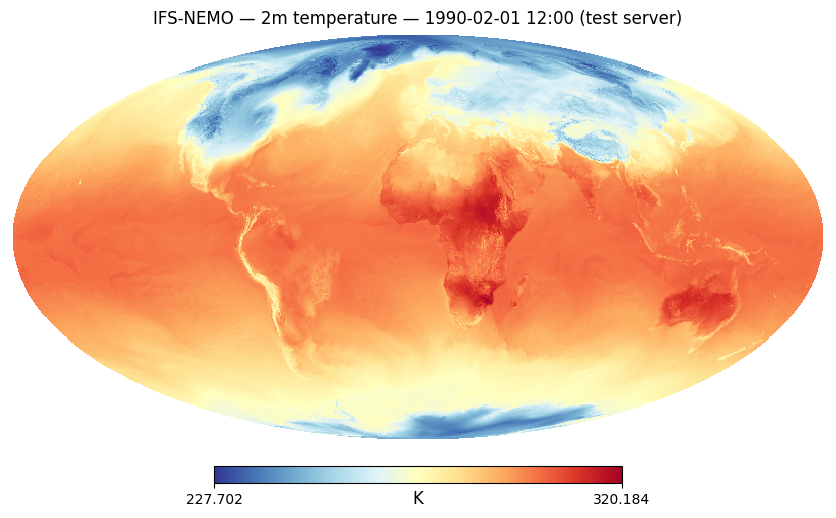

In [34]:
import healpy as hp
import matplotlib.pyplot as plt

field = ds["2t"].sel(model="IFS-NEMO", time="1990-02-01T12:00")
print(f"Fetching {dict(field.sizes)} values...")

hp.mollview(field.values, title="IFS-NEMO — 2m temperature — 1990-02-01 12:00 (test server)",
            unit="K", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

## 3. Server-side area subsetting

In [6]:
store._batch_size=23 # enforce one polytope request for this cell
area_hourly = ds["2t"].polytope.sel(
    model="IFS-NEMO",
    time=slice("1990-02-01T00:00", "1990-02-01T23:00"),
    area=(55, 5, 47, 15),
)
area_hourly

2026-04-01 18:47:04 - INFO - Key read from /Users/natr/.polytopeapirc
2026-04-01 18:47:04 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'area: 55/5/47/15\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 19900201/to/19900201\n'
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.05/0.05\n'
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            'time: '
            '0000/0100/0200/0300/0400/0500/0600/0700/0800/0900/1000/1100/1200/1300/1400/1500/1600/1700/1800/1900/2000/2100/2200/2300\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-04-01 18:47:04 - INFO - Polytope user key found in session cache for user natr


  🌍 area request for 2t (19900201/to/19900201, area=55/5/47/15, grid=0.05/0.05)


2026-04-01 18:47:05 - INFO - Request accepted. Please poll ./9a88d9ae-c23c-41f0-903c-9e089ddf99b8 for status
2026-04-01 18:47:05 - INFO - Polytope user key found in session cache for user natr
2026-04-01 18:47:05 - INFO - Checking request status (9a88d9ae-c23c-41f0-903c-9e089ddf99b8)...
2026-04-01 18:47:05 - INFO - The current status of the request is 'processing'
2026-04-01 18:47:18 - INFO - The current status of the request is 'processed'


<xarray.Dataset> Size: 6MB
Dimensions:    (time: 24, latitude: 161, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 192B 1990-02-01 ... 1990-02-01T23:00:00
  * latitude   (latitude) float64 1kB 55.0 54.95 54.9 54.85 ... 47.1 47.05 47.0
  * longitude  (longitude) float64 2kB 5.0 5.05 5.1 5.15 ... 14.9 14.95 15.0
Data variables:
    2t         (time, latitude, longitude) float64 6MB ...
Attributes:
    param:        2t
    paramId:      167
    class:        d1
    stream:       clte
    levtype:      sfc
    type:         fc
    expver:       0001
    date:         19900201
    time:         0
    domain:       g
    Conventions:  CF-1.8
    institution:  ECMWF

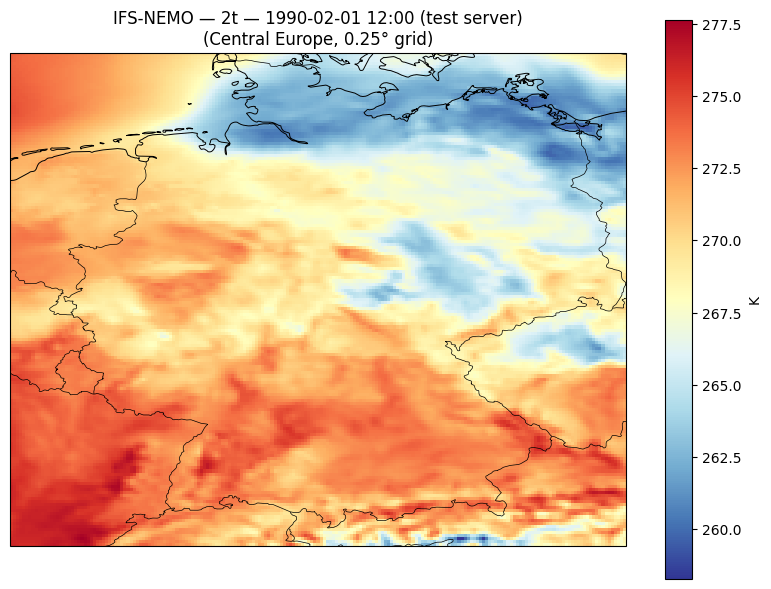

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

var_name = list(area_hourly.data_vars)[0]
field_noon = area_hourly[var_name].sel(time="1990-02-01T12:00")

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(8, 6))
field_noon.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdYlBu_r",
                cbar_kwargs={"label": "K"})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.set_title(f"IFS-NEMO — {var_name} — 1990-02-01 12:00 (test server)\n(Central Europe, 0.25° grid)")
plt.tight_layout()
plt.show()

## 4. Feature extraction — timeseries (hourly)

Hourly timeseries uses `time_axis: "date"` and returns GRIB.
This tests whether `polytope-test.mn5` has fixed the gribjump bug.

In [9]:
# Point timeseries — hourly (clte stream)
ts_result = ds["2t"].polytope.sel(
    model="IFS-NEMO",
    time=slice("1990-02-01T00:00", "1990-02-02T23:00"),
    point=(52.5, 13.4),  # Berlin
)
print(type(ts_result))
ts_result

  🌍 timeseries request for 2t (19900201/to/19900202)


<class 'dict'>


{'type': 'CoverageCollection',
 'domainType': 'PointSeries',
 'coverages': [{'mars:metadata': {'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'experiment': 'hist',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'ifs-nemo',
    'realization': 1,
    'resolution': 'high',
    'stream': 'clte',
    'type': 'fc',
    'number': 0,
    'Forecast date': '1990-02-02 00:00:00Z'},
   'type': 'Coverage',
   'domain': {'type': 'Domain',
    'axes': {'latitude': {'values': [52.464266208517]},
     'longitude': {'values': [13.438661710037]},
     'levelist': {'values': [0]},
     't': {'values': ['1990-02-01 00:00:00Z',
       '1990-02-01 01:00:00Z',
       '1990-02-01 02:00:00Z',
       '1990-02-01 03:00:00Z',
       '1990-02-01 04:00:00Z',
       '1990-02-01 05:00:00Z',
       '1990-02-01 06:00:00Z',
       '1990-02-01 07:00:00Z',
       '1990-02-01 08:00:00Z',
       '1990-02-01 09:00:00Z',
       '1990-02-01 10:00:00Z',
       '1990-0

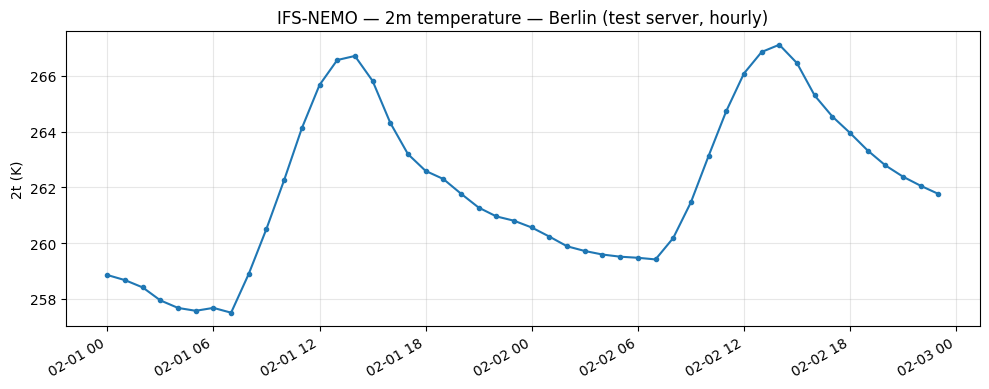

In [39]:
import pandas as pd

# Extract times and values from CoverageJSON
cov = ts_result["coverages"][0]
times = pd.to_datetime(cov["domain"]["axes"]["t"]["values"])
values = cov["ranges"]["2t"]["values"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, marker="o", markersize=3)
ax.set_ylabel("2t (K)")
ax.set_title("IFS-NEMO — 2m temperature — Berlin (test server, hourly)")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Feature extraction — bounding box

In [10]:
TEST_ADDRESS = "polytope-test.mn5.apps.dte.destination-earth.eu"

store = PolytopeZarrStore.from_climate_dt(
    models=["IFS-NEMO"],
    experiment="hist",
    levtype="sfc",
    resolution="high",
    frequency="hourly",
    start_date="1990-02-01T00:00:00",
    end_date="1990-02-02T23:00:00",
    address=TEST_ADDRESS,
)
print(store)

<PolytopeZarrStore 34 variables (time=48, cell=12582912, model=1)>


In [11]:
ds = store.open()
ds

<xarray.Dataset> Size: 82GB
Dimensions:       (model: 1, time: 48, cell: 12582912)
Coordinates:
  * model         (model) object 8B 'IFS-NEMO'
  * time          (time) datetime64[ns] 384B 1990-02-01 ... 1990-02-02T23:00:00
  * cell          (cell) int32 50MB 0 1 2 3 ... 12582909 12582910 12582911
Data variables: (12/34)
    10si          (model, time, cell) float32 2GB ...
    10u           (model, time, cell) float32 2GB ...
    10v           (model, time, cell) float32 2GB ...
    2d            (model, time, cell) float32 2GB ...
    2t            (model, time, cell) float32 2GB ...
    avg_ie        (model, time, cell) float32 2GB ...
    ...            ...
    sp            (model, time, cell) float32 2GB ...
    tcc           (model, time, cell) float32 2GB ...
    tciw          (model, time, cell) float32 2GB ...
    tclw          (model, time, cell) float32 2GB ...
    tcw           (model, time, cell) float32 2GB ...
    tcwv          (model, time, cell) float32 2GB ...
Attributes:
    _polytope_store:  <PolytopeZarrStore 34 variables (time=48, cell=12582912...

In [12]:
# Bounding box — single hour
bbox_result = ds["2t"].polytope.sel(
    model="IFS-NEMO",
    time="1990-02-01T12:00",
    bbox=(47, 5, 55, 15),  # (south, west, north, east)
)
print(type(bbox_result))
bbox_result

  🌍 boundingbox request for 2t (19900201)


<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 615kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 15363)
Coordinates:
  * datetimes  (datetimes) <U20 80B '1990-02-01T12:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 123kB 0 1 2 3 4 ... 15358 15359 15360 15361 15362
    latitude   (points) float64 123kB 47.01 47.01 47.01 ... 54.96 54.96 54.96
    longitude  (points) float64 123kB 14.74 14.54 14.64 ... 14.01 14.25 13.77
    levelist   (points) float64 123kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 123kB 271.0 ... 267.1
Attributes: (12/16)
    activity:       baseline
    class:          d1
    dataset:        climate-dt
    Forecast date:  1990-02-01T12:00:00Z
    experiment:     hist
    expver:         0001
    ...             ...
    resolution:     high
    stream:         clte
    type:           fc
    number:         0
    step:           0
    date:           1990-02-01T12:00:00Z

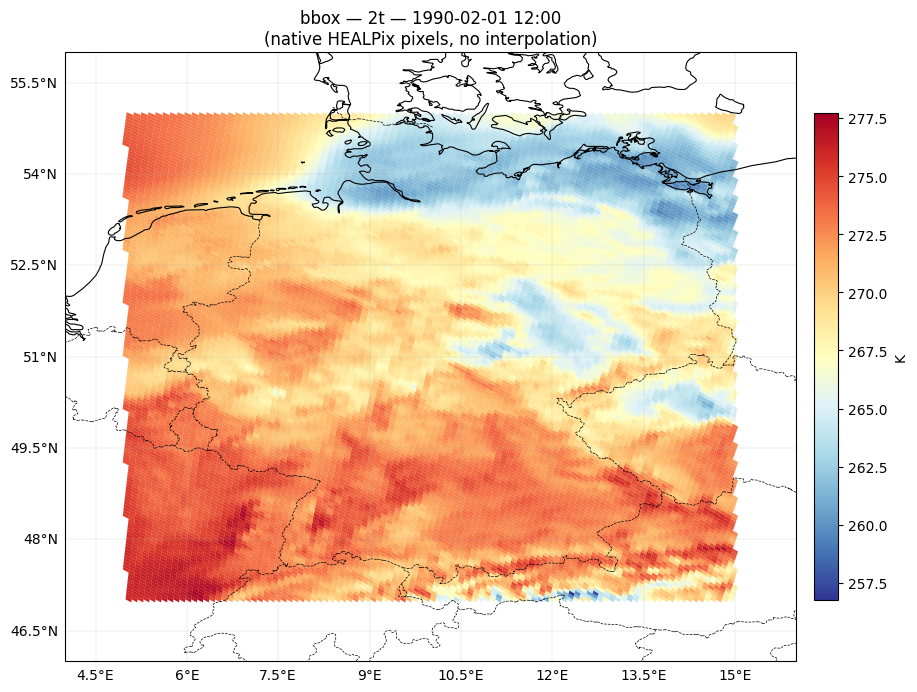

In [15]:
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
import healpy as hp

# ── Plotting a partial (bbox) HEALPix field ────────────────────────
# HEALPix is globally defined, but we do NOT need the full sky array.
# Each pixel's geometry is fully determined by just (nside, pixel_index),
# so we can compute the exact polygon boundary for any subset of pixels
# without padding, interpolation, or reconstructing the global map.
#
# Steps:
#   1. Convert the returned lat/lon → HEALPix pixel indices (ang2pix)
#   2. Get each pixel's boundary vertices (hp.boundaries) — works per-pixel
#   3. Render as filled polygons (PolyCollection) on a cartopy map

nside = store.nside
da = bbox_result["2t"].squeeze()
lats = bbox_result.coords["latitude"].values
lons = bbox_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

# Get pixel boundary vertices — only for *our* pixels, not the full sky
n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

# Convert boundary xyz → lon/lat and build polygon list
polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

# Plot with cartopy — native HEALPix cells, no interpolation
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlBu_r

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(cmap)
coll.set_norm(norm)
ax.add_collection(coll)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([4, 16, 46, 56])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title("bbox — 2t — 1990-02-01 12:00\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

## 6. Feature extraction — polygon (country cut-out)

Uses `earthkit.geo.cartography.country_polygons()` to get the boundary
of any named country, then passes it to the Polytope polygon feature.
Returns native HEALPix cells inside the country shape — no interpolation.

In [19]:
import earthkit.geo.cartography

# Get country boundary from Natural Earth via earthkit-geo
COUNTRY = "Germany"
shapes = earthkit.geo.cartography.country_polygons([COUNTRY], resolution=50e6)

poly_result = ds["2t"].polytope.sel(
    model="IFS-NEMO",
    time="1990-02-01T12:00",
    polygon=shapes,
)
print(f"{COUNTRY}: {len(shapes)} sub-polygon(s), {sum(len(s) for s in shapes)} vertices total")
print(type(poly_result))
poly_result

  🌍 polygon request for 2t (19900201)


Germany: 6 sub-polygon(s), 562 vertices total
<class 'xarray.core.dataset.Dataset'>


<xarray.Dataset> Size: 352kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 8796)
Coordinates:
  * datetimes  (datetimes) <U20 80B '1990-02-01 12:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 70kB 0 1 2 3 4 5 ... 8790 8791 8792 8793 8794 8795
    latitude   (points) float64 70kB 47.31 47.36 47.36 ... 54.87 54.87 54.87
    longitude  (points) float64 70kB 10.2 10.21 10.31 ... 8.738 8.857 8.976
    levelist   (points) float64 70kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 70kB 271.3 ... 267.0
Attributes: (12/15)
    activity:     baseline
    class:        d1
    dataset:      climate-dt
    experiment:   hist
    expver:       0001
    generation:   2
    ...           ...
    resolution:   high
    stream:       clte
    type:         fc
    number:       0
    step:         0
    date:         1990-02-01 12:00:00Z

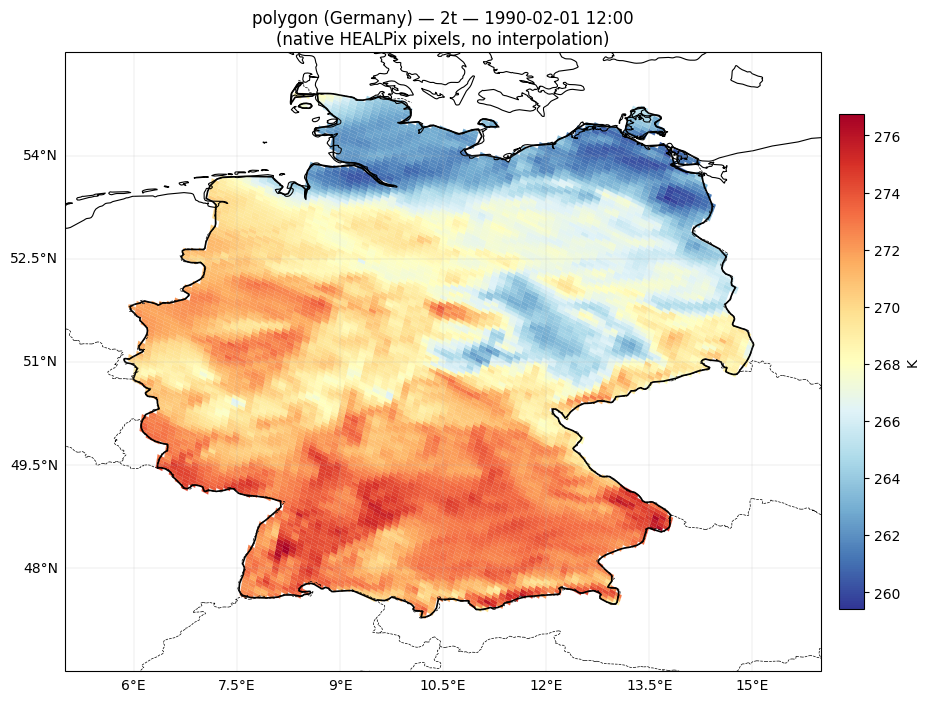

In [20]:
nside = store.nside
da = poly_result["2t"].squeeze()
lats = poly_result.coords["latitude"].values
lons = poly_result.coords["longitude"].values
values = da.values.ravel()

# HEALPix pixel indices (NESTED)
theta = np.radians(90.0 - lats)
phi = np.radians(lons)
pix_ids = hp.ang2pix(nside, theta, phi, nest=True)

n_steps = 50
boundaries = hp.boundaries(nside, pix_ids, step=n_steps, nest=True)

polygons = []
for i in range(len(pix_ids)):
    bx, by, bz = boundaries[i]
    b_lon = np.degrees(np.arctan2(by, bx))
    b_lat = np.degrees(np.arcsin(bz))
    polygons.append(list(zip(b_lon, b_lat)))

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(10, 7))

vmin, vmax = np.nanmin(values), np.nanmax(values)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

coll = PolyCollection(polygons, transform=ccrs.PlateCarree(),
                       edgecolors="face", linewidths=0.1)
coll.set_array(values)
coll.set_cmap(plt.cm.RdYlBu_r)
coll.set_norm(norm)
ax.add_collection(coll)

# Overlay country outline from earthkit-geo shapes
for shape in shapes:
    s_lons = [pt[1] for pt in shape]
    s_lats = [pt[0] for pt in shape]
    ax.plot(s_lons, s_lats, color="black", linewidth=1.2, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--")
ax.set_extent([5, 16, 46.5, 55.5])
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(coll, ax=ax, label="K", shrink=0.8, pad=0.02)
ax.set_title(f"polygon ({COUNTRY}) — 2t — 1990-02-01 12:00\n(native HEALPix pixels, no interpolation)")
plt.tight_layout()
plt.show()

In [21]:
store.clear_cache()